# Face Recognition Attendance System

An automatic attendance system that identifies people from their face images and logs each recognized person once, with the date and time.

**Approach:** classical Machine Learning — **PCA (Eigenfaces)** for feature extraction + **SVM** for classification.

**Dataset:** [AT&T Database of Faces](https://www.kaggle.com/datasets/kasikrit/att-database-of-faces) (ORL) — 40 people × 10 grayscale images (92×112 pixels) = 400 images.

**Pipeline:**

1. Load and explore the images
2. Flatten each image into a feature vector
3. Stratified train / test split (80% / 20%)
4. Dimensionality reduction with PCA
5. Train an SVM classifier
6. Evaluate the model
7. Generate the attendance sheet

> **Before running:** download the dataset and place it in `Data/att-database-of-faces/` (folders `s1` … `s40`), and run the notebook from the project's root folder.

## 1. Setup & Explore the Data

`DATA_DIR` points to the dataset folder. Each person has their own folder (`s1` … `s40`) containing 10 `.pgm` images. Below is a sample image from the first person.

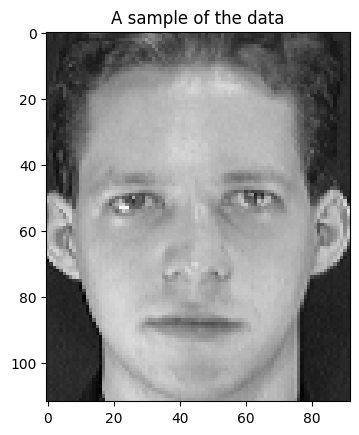

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Dataset folder (download the AT&T Database of Faces and place it inside Data/)
DATA_DIR = os.path.join('Data', 'att-database-of-faces')

img_path = os.path.join(DATA_DIR, 's1', '1.pgm')
img = Image.open(img_path)
plt.imshow(img, cmap='gray')
plt.title('A sample of the data')
plt.show()

## 2. Load the Images

Every image is converted to grayscale and **flattened** into a single vector of 10,304 pixel values (92 × 112). The folder name (`s1`, `s2`, …) is used as the person's ID (label).

Expected output: `X` of shape `(400, 10304)` and 40 unique people.

In [2]:
import os
import numpy as np

data_dir = DATA_DIR

X = []      
y = []     
for person_folder in sorted(os.listdir(data_dir)):
    person_path = os.path.join(data_dir, person_folder)
    if os.path.isdir(person_path):
        for img_name in os.listdir(person_path):
            img_path = os.path.join(person_path, img_name)
            img = Image.open(img_path).convert('L')  
            X.append(np.array(img).flatten())       
            y.append(person_folder)                  

X = np.array(X)
y = np.array(y)

print("Shape of X:", X.shape)
print("Num Person:", len(set(y)))

Shape of X: (400, 10304)
Num Person: 40


## 3. Train / Test Split

The data is split **80% / 20%** with `stratify=y`, so every person appears in both the training and the test set (8 training images and 2 test images per person). `random_state=42` keeps the split reproducible.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Number of training images:", X_train.shape[0])
print("Number of test images:", X_test.shape[0])

Number of training images: 320
Number of test images: 80


## 4. Feature Extraction — PCA (Eigenfaces)

Raw pixels (10,304 features) are highly redundant. **PCA** compresses each face into **100 principal components** (the *Eigenfaces*), keeping the most important variation while reducing noise and training time.

- `whiten=True` scales the components to unit variance.
- PCA is **fitted on the training set only**, then applied to the test set, to avoid data leakage.

In [4]:
from sklearn.decomposition import PCA

n_components = 100

pca = PCA(n_components=n_components, whiten=True, random_state=42)
pca.fit(X_train)

X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

print("Shape after PCA:", X_train_pca.shape)

Shape after PCA: (320, 100)


## 5. Train the Classifier — SVM

A **Support Vector Machine** with an RBF kernel is trained on the PCA features.

- `C=1000`, `gamma=0.001` — regularization and kernel width
- `class_weight='balanced'` — adjusts for class frequency
- `probability=True` — enables probability estimates

In [5]:
from sklearn.svm import SVC

clf = SVC(kernel='rbf', class_weight='balanced', C=1000, gamma=0.001, probability=True)
clf.fit(X_train_pca, y_train)

SVC(C=1000, class_weight='balanced', gamma=0.001, probability=True)

## 6. Evaluate the Model

The model is evaluated on the 80 unseen test images using accuracy and a per-person classification report (precision, recall, F1-score).

Result: **98.75% accuracy** — 79 of 80 test images were identified correctly.

In [6]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = clf.predict(X_test_pca)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc*100:.2f}%")

print(classification_report(y_test, y_pred))

Accuracy: 98.75%
              precision    recall  f1-score   support

          s1       1.00      1.00      1.00         2
         s10       1.00      0.50      0.67         2
         s11       1.00      1.00      1.00         2
         s12       1.00      1.00      1.00         2
         s13       1.00      1.00      1.00         2
         s14       1.00      1.00      1.00         2
         s15       1.00      1.00      1.00         2
         s16       1.00      1.00      1.00         2
         s17       1.00      1.00      1.00         2
         s18       1.00      1.00      1.00         2
         s19       1.00      1.00      1.00         2
          s2       1.00      1.00      1.00         2
         s20       1.00      1.00      1.00         2
         s21       1.00      1.00      1.00         2
         s22       1.00      1.00      1.00         2
         s23       1.00      1.00      1.00         2
         s24       1.00      1.00      1.00         2
         s

## 7. Attendance System

Each test face is passed to the classifier to predict the person's ID, then:

- ✅ if the person is **not yet marked**, a row (`Student_ID`, `Date`, `Time`) is written to `attendance.csv`
- ⚠️ if the person is **already marked**, a warning is printed and no duplicate is added

> This is a simulation that uses the dataset's test images, not a live camera feed.

In [7]:
import csv
import datetime

attendance_file = 'attendance.csv'
recorded = set()

with open(attendance_file, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Student_ID', 'Date', 'Time'])

    for face in X_test_pca:
        person = clf.predict([face])[0]

        if person in recorded:
            print(f"⚠️ {person} already marked present")
        else:
            now = datetime.datetime.now()
            writer.writerow([person, now.strftime('%Y-%m-%d'), now.strftime('%H:%M:%S')])
            recorded.add(person)
            print(f"✅ Attendance marked: {person}")

✅ Attendance marked: s29
✅ Attendance marked: s5
✅ Attendance marked: s26
✅ Attendance marked: s24
✅ Attendance marked: s9
✅ Attendance marked: s30
✅ Attendance marked: s39
✅ Attendance marked: s27
✅ Attendance marked: s12
✅ Attendance marked: s40
✅ Attendance marked: s32
✅ Attendance marked: s34
⚠️ s9 already marked present
✅ Attendance marked: s36
✅ Attendance marked: s18
⚠️ s5 already marked present
⚠️ s29 already marked present
⚠️ s40 already marked present
✅ Attendance marked: s2
✅ Attendance marked: s6
✅ Attendance marked: s33
⚠️ s27 already marked present
✅ Attendance marked: s3
⚠️ s3 already marked present
✅ Attendance marked: s8
✅ Attendance marked: s19
✅ Attendance marked: s38
✅ Attendance marked: s20
⚠️ s19 already marked present
✅ Attendance marked: s14
⚠️ s34 already marked present
⚠️ s8 already marked present
✅ Attendance marked: s23
⚠️ s29 already marked present
✅ Attendance marked: s7
⚠️ s32 already marked present
✅ Attendance marked: s28
✅ Attendance marked: s22
✅ Atte

## 8. View the Attendance Sheet

Load the generated `attendance.csv` and check how many people were marked present (all 40 in this run).

In [8]:
import pandas as pd

df = pd.read_csv(attendance_file)
print(f"Total students marked present: {len(df)}")
df

Total students marked present: 40


,Student_ID,Date,Time
0,s29,2026-09-16,09:33:16
1,s5,2026-09-16,09:33:16
2,s26,2026-09-16,09:33:16
3,s24,2026-09-16,09:33:16
4,s9,2026-09-16,09:33:16
5,s30,2026-09-16,09:33:16
6,s39,2026-09-16,09:33:16
7,s27,2026-09-16,09:33:16
8,s12,2026-09-16,09:33:16
9,s40,2026-09-16,09:33:16


## Conclusion

A simple PCA + SVM pipeline reaches **98.75% accuracy** on the AT&T faces dataset and can drive an automatic attendance sheet.

**Limitations & possible improvements**

- The system does **closed-set identification** — it can only recognize the 40 people it was trained on.
- The dataset was captured under controlled conditions; real-world lighting and angles will reduce accuracy.
- Next steps: add face detection (e.g. OpenCV) for live camera input, try a CNN / deep face embeddings, and add an "unknown person" rejection threshold using the predicted probabilities.